# Classification with PyTorch


## Parte 1: Clasificación de Iris
El conjunto de datos Iris contiene 150 registros de 3 clases diferentes de iris. Cada registro contiene 4 parámetros numéricos: largo/ancho del sépalo y largo/ancho del pétalo. Es un ejemplo de un conjunto de datos simple, para el cual no necesitas una red neuronal poderosa.

Obtener el conjunto de datos
El conjunto de datos Iris está incorporado en Scikit Learn, así que podemos obtenerlo fácilmente:

### Dataset

El conjunto de datos Iris está incorporado en Scikit Learn, así que podemos obtenerlo fácilmente:

In [13]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
features = iris['data']
labels = iris['target']
class_names = iris['target_names']
feature_names = iris['feature_names']

print(f"Features: {feature_names}, Classes: {class_names}")

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'], Classes: ['setosa' 'versicolor' 'virginica']


### Visualizar los Datos

En muchos casos, tiene sentido visualizar los datos para ver si parecen separables; esto nos aseguraría que deberíamos poder construir un buen modelo de clasificación. Como tenemos pocas características, podemos construir una serie de gráficos de dispersión 2D por pares, mostrando diferentes clases con diferentes colores de puntos. Esto se puede hacer automáticamente con un paquete llamado **seaborn**:

In [14]:
import seaborn as sns
import pandas as pd

df = pd.DataFrame(features,columns=feature_names).join(pd.DataFrame(labels,columns=['Label']))

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Label
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


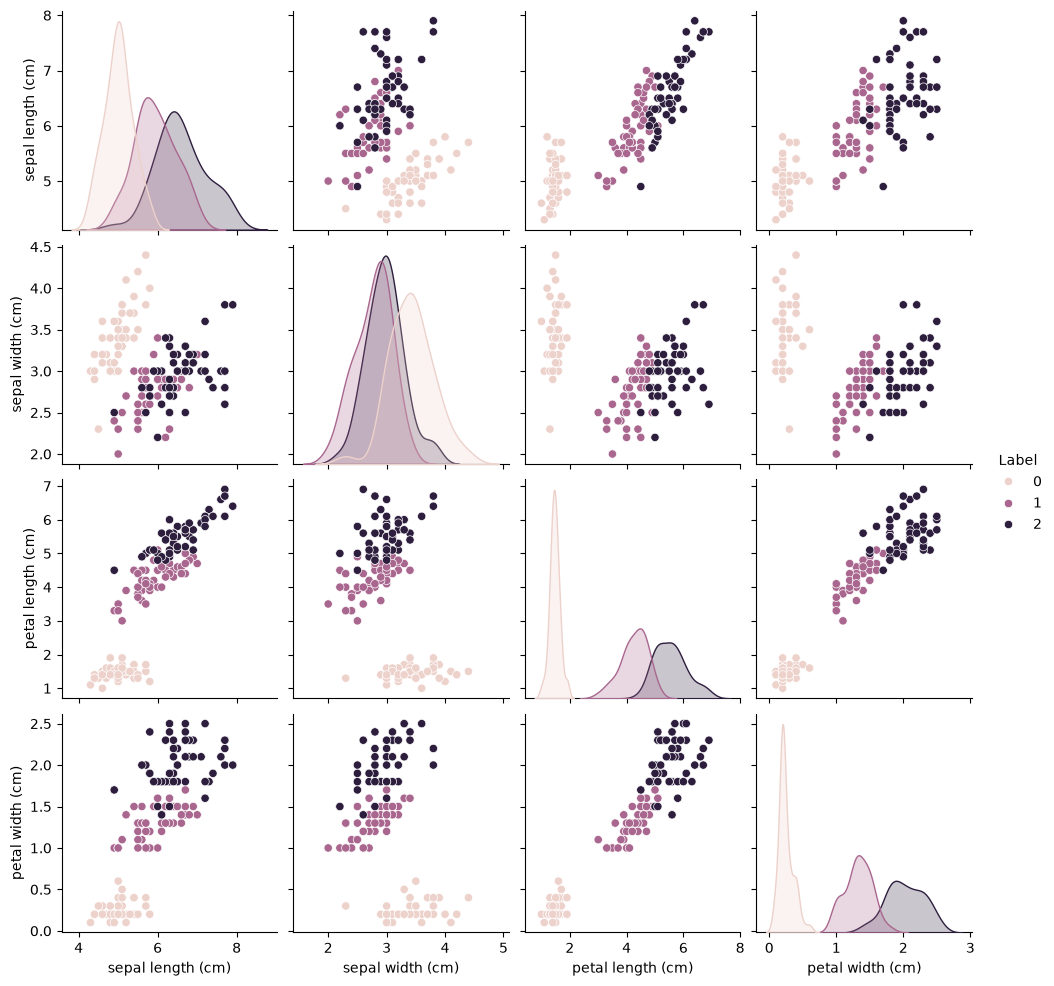

In [4]:
sns.pairplot(df,hue='Label')

### Normalizar y Codificar 

Para preparar los datos para el entrenamiento de la red neuronal, necesitamos normalizar las entradas en el rango [0..1]. Esto se puede hacer usando operaciones de numpy o métodos de Scikit Learn.


In [15]:
# Code to normalize and encode the data
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df[feature_names], df['Label'], test_size=0.2, random_state=42)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
y_train = y_train.values
y_test = y_test.values  

### Train/Test Data Split

Como no tenemos un conjunto de datos de entrenamiento y prueba por separado, necesitamos dividirlo en conjuntos de entrenamiento y prueba usando Sklearn

[using Sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [17]:
import torch 
from torch.utils.data import DataLoader, TensorDataset

X_train=X_train.astype('float32')
X_test=X_test.astype('float32')
y_train=y_train.astype('int32')
y_test=y_test.astype('int32')   

X_train_torch = torch.from_numpy(X_train)
X_test_torch = torch.from_numpy(X_test)
y_test_torch = torch.from_numpy(y_test).float()
# On some computers the explicit cast to .float() is
# necessary
y_train_torch = torch.from_numpy(y_train).float()

train_ds = TensorDataset(X_train_torch, y_train_torch)

batch_size = X_train.shape[0]//4
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [18]:
for xb,yb in train_dl:
    print(xb.shape)
    print(yb.shape)
    break

torch.Size([30, 4])
torch.Size([30])


In [19]:
yb

tensor([0., 2., 1., 2., 2., 0., 2., 1., 1., 1., 1., 1., 0., 0., 0., 1., 2., 0.,
        1., 0., 0., 0., 2., 0., 2., 1., 1., 1., 2., 0.])

### Define y Entrena Red Neuronal

Define la red neuronal y comienza el entrenamiento, observando el comportamiento de la precisión de entrenamiento y validación.

```
import torch 
from torch import nn

net = nn.Sequential(nn.Linear(4, 32),
                    nn.ReLU(),
                    nn.Linear(32, 3));
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);
```

In [36]:
# Define the network
# 
import torch 
from torch import nn

net = nn.Sequential(nn.Linear(4, 32),
                    nn.ReLU(),
                    nn.Linear(32, 3));


def init_weights(m, std=0.001):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=std)

net.apply(init_weights);

In [39]:
import torch.nn as nn 

optimizer = torch.optim.SGD(net.parameters(), lr=1e-1, momentum=0.9)
loss = nn.CrossEntropyLoss()

losses=dict()
init_std={1e-3:0.001, 1e-2:0.01, 1e-1:0.1, 1:1}
losses={std:[] for std in init_std.values()}
for std in init_std.values():
    net.apply(lambda m: init_weights(m, std=std))
    for i in range(100):
        for xb,yb in train_dl:
            y_hat= net(xb)
            output = loss(y_hat,yb.long())
            if i % 30 == 0:
                print(f"std: {std}, Epoch {i}, Loss value: {output.item()}")
            output.backward()
            optimizer.step()
            optimizer.zero_grad()
            losses[std].append(output.item())

std: 0.001, Epoch 0, Loss value: 2.559281349182129
std: 0.001, Epoch 0, Loss value: 3.6522562503814697
std: 0.001, Epoch 0, Loss value: 3.235520124435425
std: 0.001, Epoch 0, Loss value: 3.7307350635528564
std: 0.001, Epoch 30, Loss value: 0.19027157127857208
std: 0.001, Epoch 30, Loss value: 0.10003524273633957
std: 0.001, Epoch 30, Loss value: 0.1612158566713333
std: 0.001, Epoch 30, Loss value: 0.15180210769176483
std: 0.001, Epoch 60, Loss value: 0.11969789862632751
std: 0.001, Epoch 60, Loss value: 0.10919865220785141
std: 0.001, Epoch 60, Loss value: 0.09572722017765045
std: 0.001, Epoch 60, Loss value: 0.0923183336853981
std: 0.001, Epoch 90, Loss value: 0.10042109340429306
std: 0.001, Epoch 90, Loss value: 0.0863446369767189
std: 0.001, Epoch 90, Loss value: 0.14100994169712067
std: 0.001, Epoch 90, Loss value: 0.05672323703765869
std: 0.01, Epoch 0, Loss value: 7.1338653564453125
std: 0.01, Epoch 0, Loss value: 5.360169410705566
std: 0.01, Epoch 0, Loss value: 6.71494770050048

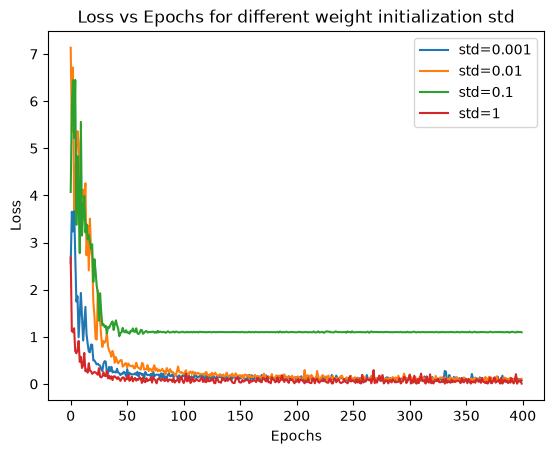

In [42]:
plt.plot(losses[0.001], label='std=0.001')
plt.plot(losses[0.01], label='std=0.01')
plt.plot(losses[0.1], label='std=0.1')
plt.plot(losses[1], label='std=1')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs for different weight initialization std')
plt.legend()

<BarContainer object of 4 artists>

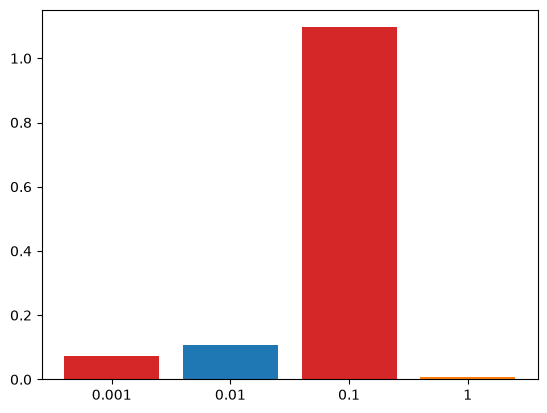

In [44]:
import matplotlib.pyplot as plt

bar_labels = ['red', 'blue', '_red', 'orange']
bar_colors = ['tab:red', 'tab:blue', 'tab:red', 'tab:orange']
categories = list(str(std) for std in losses.keys())
values = [losses[std][-1] for std in losses.keys()]
plt.bar(categories, values, label=bar_labels, color=bar_colors)

In [5]:
# Train the network

In [6]:
# Visualize train/validation accuracy graph

### Experimento

Ahora puedes experimentar con diferentes arquitecturas de red para ver cómo afecta el resultado. Prueba:

1. Red de una sola capa con 3 neuronas (igual al número de clases)
2. Red de dos capas con una capa oculta pequeña/mediana/grande
3. Usar más capas y mayor profundidad

Asegúrate de observar sobreajuste cuando uses un modelo complejo con muchas neuronas (parámetros).

In [7]:
# Experiment